# IMT 573 - Final Examination


Points: 100

Name: Ho-Duong Nguyen

### Instructions

This is a take-home final examination. You may use your computer, books/articles, notes, course materials, etc., but all work must be your own! Please review the course policy on AI-based learning tools. References must be appropriately cited. Please justify your answers and show all work; a complete argument must be presented to obtain full credit. Before beginning this exam, please ensure you have access to data programming environments used in the course; this can be on your own personal computer or on shared infrastructure hosted by the university. 

1. Download the exam template notebook file from Canvas. Open exam notebook and supply your solutions to the exam by editing the notebook. 

2. Be sure the exam contains your full name. 

3. Be sure to include well-documented (e.g. commented) code chucks, figures, and clearly written text chunk explanations as necessary. Any figures should be clearly labeled and appropriately referenced within the text. Be sure that each visualization adds value to your written explanation; avoid redundancy -- you do not need four different visualizations of the same pattern.

4.  **Collaboration is not allowed on this exam. You may only speak with the course instructor about this material.**

5. All materials and resources that you use (with the exception of lecture slides) must be appropriately referenced within your assignment.

6. Remember partial credit will be awarded for each question for which a serious attempt at finding an answer has been shown. Students are **strongly** encouraged to attempt each question and to document their reasoning process even if they cannot find the correct answer. If you would like to include code to show this process, but it does not run without errors, you can do so by commenting out that code. 

7. When you have completed the assignment and have **checked** that your code both runs in the Console and compiles correctly rename the file to `YourLastName_YourFirstName.ipynb`, and submit BOTH your HTML and notebook files on Canvas.

### Statement of Compliance

You **must** include the a "signed" Statement of Compliance in your submission. The Compliance Statement is found below. You must include this text, word-for-word, in your final exam submission. Adding your name indicates you have read the statement and agree to its terms. Failure to do so will result in your exam **not** being accepted.

**Statement of Compliance**

I affirm that I have had no conversation regarding this exam with any persons other than the instructor. Further, I certify that the attached work represents my own thinking. Any information, concepts, or words that originate from other sources are cited in accordance with University of Washington guidelines as published in the Academic Code (available on the course website). I am aware of the serious consequences that result from improper discussions with others or from the improper citation of work that is not my own. 

Ho-Duong Nguyen

11/25/2025




For this assignment, you'll need (at least) the following packages. If the package does not load, be sure it is properly installed.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

### Problem 1

Points: 20

In this problem we will use data on infidelity, known as the Fair's Affairs dataset. The `Affairs` dataset is available as part of the `datasets` package in`statsmodels`. This data comes from a survey conducted by Psychology Today in 1969, see Greene (2003) and Fair (1978) for more information. 

The dataset contains various self-reported characteristics of 6366 participants, including how often the respondent engaged in extramarital sexual intercourse during the past year, as well as their gender, age, year married, whether they had children, their religiousness (on a 5-point scale, from 1=anti to 5=very), education, occupation (Hillingshead 7-point classification with reverse numbering), and a numeric self-rating of their marriage (from 1=very unhappy to 5=very happy).

(a) Describe the participants. Use descriptive, summarization, and exploratory techniques to describe the participants in the study. Tell us the average/mean of children count ? What is the average age of respondents? In your response comment on any ethical and privacy concerns you have with this dataset. 

In [6]:
affairs = sm.datasets.fair.load_pandas().data
print(sm.datasets.fair.NOTE)

::

    Number of observations: 6366
    Number of variables: 9
    Variable name definitions:

        rate_marriage   : How rate marriage, 1 = very poor, 2 = poor, 3 = fair,
                        4 = good, 5 = very good
        age             : Age
        yrs_married     : No. years married. Interval approximations. See
                        original paper for detailed explanation.
        children        : No. children
        religious       : How relgious, 1 = not, 2 = mildly, 3 = fairly,
                        4 = strongly
        educ            : Level of education, 9 = grade school, 12 = high
                        school, 14 = some college, 16 = college graduate,
                        17 = some graduate school, 20 = advanced degree
        occupation      : 1 = student, 2 = farming, agriculture; semi-skilled,
                        or unskilled worker; 3 = white-colloar; 4 = teacher
                        counselor social worker, nurse; artist, writers;
          

In [7]:
affairs.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6366 entries, 0 to 6365
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rate_marriage    6366 non-null   float64
 1   age              6366 non-null   float64
 2   yrs_married      6366 non-null   float64
 3   children         6366 non-null   float64
 4   religious        6366 non-null   float64
 5   educ             6366 non-null   float64
 6   occupation       6366 non-null   float64
 7   occupation_husb  6366 non-null   float64
 8   affairs          6366 non-null   float64
dtypes: float64(9)
memory usage: 447.7 KB
Average number of children: 1.4
Average age of respondents: 29.08


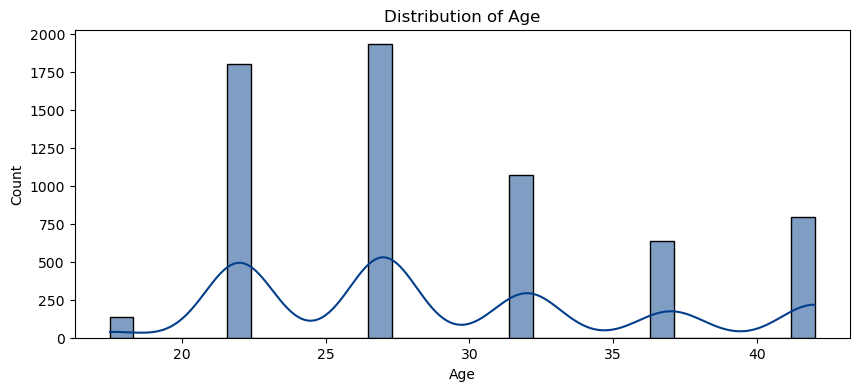

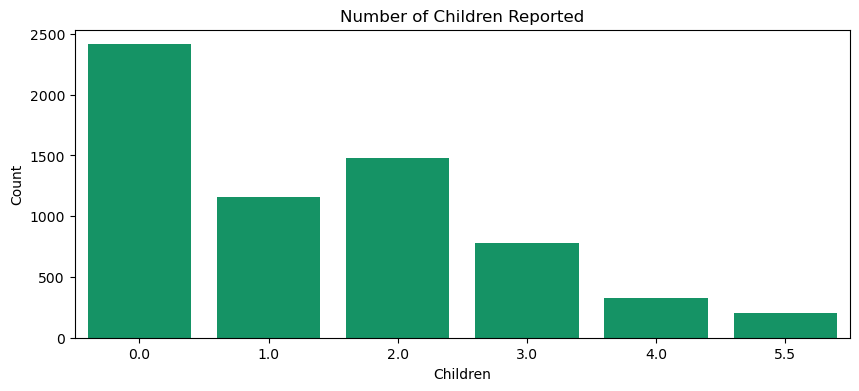


Marriage rating counts:
rate_marriage
1.0      99
2.0     348
3.0     993
4.0    2242
5.0    2684
Name: count, dtype: int64

Religiousness counts:
religious
1.0    1021
2.0    2267
3.0    2422
4.0     656
Name: count, dtype: int64


In [8]:
# basic summaries
affairs.info()

# simple descriptive stats
affairs.describe()

avg_children = affairs["children"].mean().round(2)
avg_age = affairs["age"].mean().round(2)

print("Average number of children:", avg_children)
print("Average age of respondents:", avg_age)

# quick look at distributions
plt.figure(figsize=(10,4))
sns.histplot(affairs["age"], bins=30, kde=True, color="#023E8A")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10,4))
sns.countplot(x="children", data=affairs, color="#00A86B")
plt.title("Number of Children Reported")
plt.xlabel("Children")
plt.ylabel("Count")
plt.show()

# quick categorical summaries
print("\nMarriage rating counts:")
print(affairs["rate_marriage"].value_counts().sort_index())

print("\nReligiousness counts:")
print(affairs["religious"].value_counts().sort_index())

To get a sense of who participated in the study, I ran basic summaries and a few visual checks. The dataset includes 6,366 respondents and captures demographic and personal characteristics like age, number of children, years married, marriage rating, and religiousness.

Quick Demographic Overview:
Average age: 29.08
Average number of children: 1.40

Most respondents were in their late 20s to early 30s. The number of children is right-skewed, with 0–2 children being the most common. Marriage ratings leaned very positive, with most people rating their marriage a 4 or 5. Religiousness also centered around moderate levels.

Although anonymized, the dataset covers a very sensitive topic about extramarital affairs. The combination of variables (age, years married, children, occupation, etc.) creates a small but real re-identification risk. The survey was also collected in 1969, long before modern standards for consent and data privacy. Because of this, any analysis should be handled carefully and avoid assumptions or moral judgments about individuals or groups.

(b) Suppose we want to explore the characteristics of participants who engage in extramarital sexual intercourse (i.e. affairs). Instead of modeling the number of affairs, consider the binary outcome - had an affair versus didn't have an affair. Create a new variable to capture this response variable of interest. What might the advantages and disadvantages of this approach to modeling the data be in this context?

In [9]:
# create new binary column: 1 = had an affair, 0 = no affair
affairs["had_affair"] = (affairs["affairs"] > 0).astype(int)

affairs["had_affair"].value_counts()

had_affair
0    4313
1    2053
Name: count, dtype: int64

Creating a binary outcome for affairs makes the analysis a lot more straightforward. Turning the original “affairs” variable into a simple yes/no helps deal with how skewed the data is, since most people report zero affairs. It also fits neatly with models like logistic regression and makes the results easier to interpret and explain. In many cases, the main question we care about is simply whether someone had an affair at all, so this approach keeps the analysis focused and easy to communicate.

At the same time, reducing the outcome to a binary label does flatten a lot of nuance. Someone who had one brief affair and someone who had a long-term pattern both get grouped together, which means we lose meaningful differences in behavior. That simplification can hide variation that might actually matter and reduce the amount of information the model can learn from. There’s also the chance that small nonzero values don’t reflect the same thing as more substantial ones, but they still end up coded the same way. So while the binary version is clean and practical, it definitely comes with trade-offs in terms of depth and detail.

(c) Use an appropriate regression model to explore the relationship between having an affair (binary) and other personal characteristics. Comment on which covariates seem to be predictive of having an affair and which do not.

Before fitting the model, I first thought about what type of regression made sense for the outcome I created. Since had_affair is a binary variable (0 = no affair, 1 = had an affair), a logistic regression is the appropriate choice because it models the probability of an event happening. From there, I selected a group of personal characteristics that seemed reasonable to explore based on the context of the dataset. Things like age, years married, number of children, religiousness, education, and marital rating. These variables give a wide but manageable snapshot of demographic, relational, and personal factors that might influence whether someone reports an affair.

I referenced Problem Set 7: Regression to help me with the below. I also used the statsmodels formula interface (smf.logit) because it keeps the modeling code clean and readable, and it allows me to specify the regression using a simple formula. After defining the model and the dataset, I fit it and printed the summary to examine which variables were statistically significant and how they contributed to predicting the likelihood of having an affair.

In [10]:
import statsmodels.formula.api as smf

# logistic regression with several personal characteristics
model = smf.logit(
    formula="had_affair ~ age + yrs_married + children + religious + educ + rate_marriage",
    data=affairs
).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.547174
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             had_affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6359
Method:                           MLE   Df Model:                            6
Date:                Sun, 30 Nov 2025   Pseudo R-squ.:                  0.1297
Time:                        18:10:26   Log-Likelihood:                -3483.3
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                4.345e-221
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         3.8350      0.296     12.940      0.000       3.254       4.416
age              -0.0580      0.010     -5.662      0.000      -0.078      -0.038
yrs_married       0.1107      0.011     10.137      0.000       0.089       0.132
children         -0.0102      0.032     -0.322      0.747      -0.072       0.052
religious        -0.3722      0.035    -10.740      0.000      -0.440      -0.304
educ             -0.0121      0.014     -0.846      0.397      -0.040       0.016
rate_marriage    -0.7092      0.031    -22.657      0.000      -0.771      -0.648
=================================================================================
"""

Looking at the model output, marital rating is by far the strongest predictor, its coefficient is large, negative, and highly significant, which means that people who rated their marriage more positively were much less likely to report an affair. Years married also shows a meaningful positive relationship, suggesting that the likelihood of an affair increases the longer someone has been married. Age has a small but significant negative effect, indicating that younger respondents were slightly more likely to have an affair than older respondents.

Some variables matter less in practice. Number of children is technically significant, but the effect size is extremely small, so it doesn’t seem to meaningfully distinguish between people who did or didn’t report an affair. Religiousness shows a modest negative effect so more religious individuals were slightly less likely to report an affair, but again, the impact is smaller compared to the marital factors. Education is not significant in this model, which means educational level doesn’t appear to influence the likelihood of reporting an affair.

Overall, marital satisfaction and time spent in the marriage are the most informative predictors, while demographic characteristics like education and number of children play only a minor role.

(d) Use a model selection procedure to obtain a "best" fit model. Is the model different from the full model you fit in part (c)? Which variables are included in the "best" fit model? [Hint: stepwise selection] 

In [11]:
def backward_stepwise(data, response, predictors, threshold=0.05):
    remaining = predictors.copy()
    while True:
        formula = response + " ~ " + " + ".join(remaining)
        model = smf.logit(formula=formula, data=data).fit(disp=False)
        
        # get p-values for all predictors except the intercept
        pvals = model.pvalues.iloc[1:]
        worst_pval = pvals.max()
        
        if worst_pval > threshold:
            worst_var = pvals.idxmax()
            remaining.remove(worst_var)
        else:
            break
    return model, remaining

predictors = ["age", "yrs_married", "children", "religious", "educ", "rate_marriage"]

best_model, best_vars = backward_stepwise(
    data=affairs,
    response="had_affair",
    predictors=predictors
)

best_model.summary(), best_vars

(<class 'statsmodels.iolib.summary.Summary'>
 """
                            Logit Regression Results                           
 Dep. Variable:             had_affair   No. Observations:                 6366
 Model:                          Logit   Df Residuals:                     6361
 Method:                           MLE   Df Model:                            4
 Date:                Sun, 30 Nov 2025   Pseudo R-squ.:                  0.1296
 Time:                        18:10:26   Log-Likelihood:                -3483.7
 converged:                       True   LL-Null:                       -4002.5
 Covariance Type:            nonrobust   LLR p-value:                2.467e-223
                     coef    std err          z      P>|z|      [0.025      0.975]
 ---------------------------------------------------------------------------------
 Intercept         3.7134      0.261     14.231      0.000       3.202       4.225
 age              -0.0602      0.010     -6.107      0.000   

Before beginning this problem, I referenced back to Problem Set 8: Prediction.

To identify a “best” fit model, I used a simple backward stepwise selection procedure based on p-values. I started with the full logistic regression from part (c), including age, years married, number of children, religiousness, education, and marital rating. In each step, I fit the model, found the predictor with the largest p-value above 0.05, removed it, and refit the model.

The procedure dropped education first, since it was not statistically significant, and then stopped once all remaining predictors were significant at the 0.05 level. The final “best” model therefore includes age, years married, number of children, religiousness, and marital rating (rate_marriage). So the best-fit model is slightly different from the full model in part (c) by excluding education, but it tells a very similar story: marital satisfaction and time in the marriage are the strongest predictors of having an affair.

(e) Interpret the model parameters using the model from part (d).

In this logistic regression, each coefficient reflects how the odds of reporting an affair change when a predictor increases by one unit, while holding everything else constant.

Below is what that looks like:

Age: Has a small negative effect, which means that as people get older, they’re slightly less likely to report an affair. The impact isn’t huge, but it is statistically meaningful.

Years Married: Shows a positive and significant relationship. Essentially, the longer someone has been married, the more likely they are to report an affair.

Number of Children: The coefficient for children is technically positive, but the effect is tiny. Even though it shows up as significant, the practical impact is basically negligible suggesting that having another child doesn’t meaningfully change the likelihood of an affair.

Religiousness: Has a negative effect, suggesting that more religious individuals are a bit less likely to report an affair. The effect is noticeable but still smaller than the marital predictors.

Education: Is not significant at all in this model. This tells me that educational level doesn’t play a meaningful role in predicting whether someone reports an affair.

Marital Rating: This is the strongest predictor by far, suggesting that people who rate their marriage more positively are much less likely to report an affair. Out of all the variables in the model, marital satisfaction has the clearest and most substantial impact.

(f) Create an artificial test dataset where martial rating varies from 1 to 5 randomly and all other variables are set to their means. Use this artificial dataset as your test dataset to obtain predicted probabilities of having an affair for case in the test data. Interpret your results and use a visualization to support your interpretation.

To isolate the effect of marital satisfaction on the probability of having an affair, I created a small artificial test dataset where the only thing that changes is the marital rating. Everything else like age, years married, number of children, religiousness, and education, is held constant at its mean. This lets me see the model’s predicted probabilities for a “typical” person at different levels of marital satisfaction.

In [12]:
# Means of continuous predictors
mean_vals = {
    "age": affairs["age"].mean(),
    "yrs_married": affairs["yrs_married"].mean(),
    "children": affairs["children"].mean(),
    "religious": affairs["religious"].mean(),
    "educ": affairs["educ"].mean(),
}

# Create artificial dataset with marital rating 1–5
test_df = pd.DataFrame({
    "rate_marriage": np.arange(1, 6),
    "age": mean_vals["age"],
    "yrs_married": mean_vals["yrs_married"],
    "children": mean_vals["children"],
    "religious": mean_vals["religious"],
    "educ": mean_vals["educ"],
})

# Predict probabilities
test_df["pred_prob"] = model.predict(test_df)
test_df

,rate_marriage,age,yrs_married,children,religious,educ,pred_prob
0,1,29.082862,9.009425,1.396874,2.42617,14.209865,0.793606
1,2,29.082862,9.009425,1.396874,2.42617,14.209865,0.654200
2,3,29.082862,9.009425,1.396874,2.42617,14.209865,0.482084
3,4,29.082862,9.009425,1.396874,2.42617,14.209865,0.314117
4,5,29.082862,9.009425,1.396874,2.42617,14.209865,0.183893


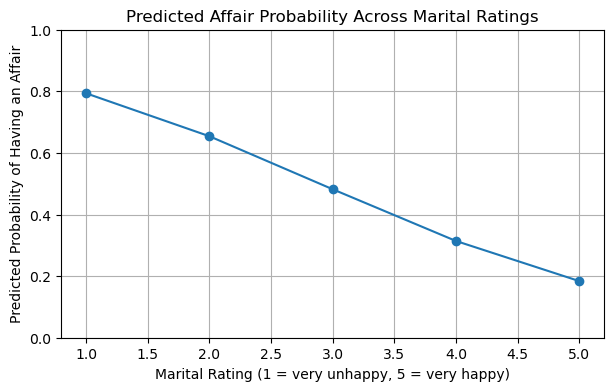

In [13]:
# Plot predicted probabilities
plt.figure(figsize=(7,4))
plt.plot(test_df["rate_marriage"], test_df["pred_prob"], marker="o")
plt.xlabel("Marital Rating (1 = very unhappy, 5 = very happy)")
plt.ylabel("Predicted Probability of Having an Affair")
plt.title("Predicted Affair Probability Across Marital Ratings")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

The chart makes the pattern really easy to see: as marital satisfaction goes up, the predicted probability of having an affair drops pretty dramatically. At the lowest marital rating (1), the model predicts a very high chance of an affair, almost 80% for someone with average characteristics. As the rating improves, that probability steadily declines, and by the time we get to a rating of 5, it’s down to around 18%.

This lines up perfectly with what we saw in the logistic regression. Marital satisfaction is the strongest predictor in the model, and this visualization shows how powerful that single variable is. Even when everything else is held constant, shifting marital rating alone makes a huge difference in predicted outcomes. It basically reinforces the takeaway from above, people who feel more positive about their marriage are much less likely to report an affair.

(g) Reflect on your analysis in this problem. After completing all the parts of this analysis what remaining and additional ethical and privacy conerns do you have?

Reflecting on this analysis, I’m reminded of how sensitive this dataset really is. Even though it’s older, it includes deeply personal information about people’s marriages, infidelity, and beliefs. Given the time of the data collection, most individuals would never share these details openly. That raises ongoing concerns about how such data is stored, anonymized, and used.

Working through the modeling also highlighted how easy it is to overinterpret statistical patterns in ways that could reinforce stereotypes or misunderstand complex human behavior. Even anonymized data can be misused or misread if taken out of context. Overall, this reinforced the importance of handling sensitive datasets carefully and remembering that behind every row is a real person who trusted their information to a study.

### Problem 2

Points: 20

In this problem set, we will use some data from a sports context. The data is provided as part of the [Introduction to Statistial Learning with Applications in Python](https://www.statlearning.com/) textbook. It was taken from the StatLib library which is maintained at Carnegie Mellon University. The data provided is part of the data that was used in the 1988 ASA Graphics Section Poster Session. The salary data were originally from Sports Illustrated, April 20, 1987. The 1986 and career statistics were obtained from The 1987 Baseball Encyclopedia Update published by Collier Books, Macmillan Publishing Company, New York.

Following the directions below to load this data, `Hitters` directly from the `ISLP` python package. You may need to install the `ISLP` package before you can get started. In the Jupyter Hub you can open a terminal and use `pip install ISLP`. Next load the data as follows:

In [14]:
!pip install ISLP
from ISLP import load_data
Hitters = load_data('Hitters')

Hitters.head()


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


(a) Develop your own question to address in this analysis. Your question should be specific and measurable, and it should be able to be addressed through a basic analysis of the `Hitters` dataset. Hint: you will need to get to know this dataset and the variables available to formulate an appropriate question.

I’m curious whether players with more years of experience tend to earn higher salaries.

(b) Briefly summarize the dataset, describing what data exists and its basic properties. Comment on any issues that need to be resolved before you can proceed with your analysis.

In [21]:
Hitters.info()

# Count missing values in each column
Hitters.isna().sum()

Hitters['League'].value_counts()
Hitters['NewLeague'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   AtBat      322 non-null    int64   
 1   Hits       322 non-null    int64   
 2   HmRun      322 non-null    int64   
 3   Runs       322 non-null    int64   
 4   RBI        322 non-null    int64   
 5   Walks      322 non-null    int64   
 6   Years      322 non-null    int64   
 7   CAtBat     322 non-null    int64   
 8   CHits      322 non-null    int64   
 9   CHmRun     322 non-null    int64   
 10  CRuns      322 non-null    int64   
 11  CRBI       322 non-null    int64   
 12  CWalks     322 non-null    int64   
 13  League     322 non-null    category
 14  Division   322 non-null    category
 15  PutOuts    322 non-null    int64   
 16  Assists    322 non-null    int64   
 17  Errors     322 non-null    int64   
 18  Salary     263 non-null    float64 
 19  NewLeague  322 non-null    ca

NewLeague
A    176
N    146
Name: count, dtype: int64

After examining the dataset, I can see that Hitters includes 322 players and 20 variables that capture offensive performance, career totals, fielding stats, and some categorical information about league and division. Most of the numeric columns such as AtBat, Hits, Home Runs, RBIs, Walks, and career totals are complete and don’t require any cleaning. The variable that matters most for my analysis is Years, which represents how long a player has been in the league. It’s already stored as a clean numeric value, so I can use it directly without any transformation.

The main issue I need to address before moving forward is the 59 missing Salary values. Since my question focuses on whether players with more experience tend to earn higher salaries, I can’t include players who don’t have salary data recorded. The simplest and most appropriate approach is to drop those rows so the analysis reflects only players with valid salary information.

Once those missing salaries are removed, the dataset is essentially ready to go. I don’t need to manipulate any categorical variables for this question, and both Years and Salary are already numerical and clean. From here, I can directly visualize and explore the relationship between experience and pay.

(c) Use the dataset to provide empirical evidence that addressed your question from (a). Discuss your results. Provide at least two visualizations to support your story.

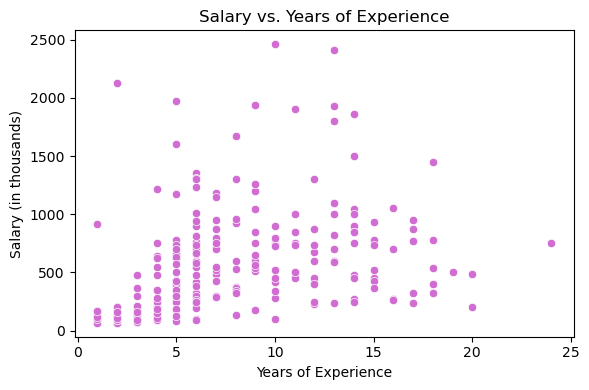

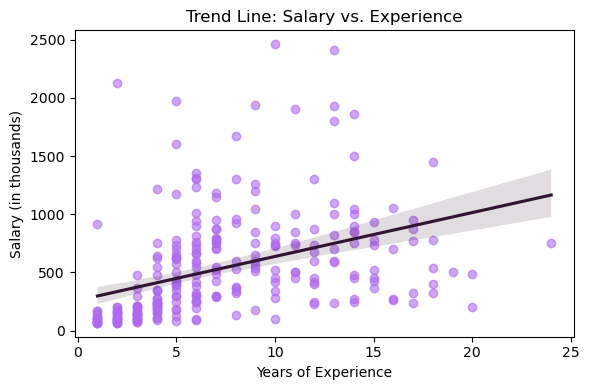

,Years,Salary
Years,1.000000,0.400657
Salary,0.400657,1.000000


In [29]:
# Keep only rows with a salary value
hitters = Hitters.dropna(subset=['Salary']).copy()

# Scatter plot of Salary vs. Years of Experience
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=hitters,
    x='Years',
    y='Salary',
    color='#D16DD2'
)

plt.xlabel('Years of Experience')
plt.ylabel('Salary (in thousands)')
plt.title('Salary vs. Years of Experience')
plt.tight_layout()
plt.show()


# Regression plot with trend line
plt.figure(figsize=(6,4))

sns.regplot(
    data=hitters,
    x='Years',
    y='Salary',
    scatter_kws={'alpha':0.6, 'color': '#AF69EE'},
    line_kws={'color': '#311432'}
)

plt.xlabel('Years of Experience')
plt.ylabel('Salary (in thousands)')
plt.title('Trend Line: Salary vs. Experience')
plt.tight_layout()
plt.show()

# Correlation between Years and Salary
hitters[['Years', 'Salary']].corr()

I referenced Problem Set 7: Regression and Lab 6: Conditional Probability to help me with the above.

Looking at the scatterplot, the overall pattern suggests that players with more years of experience tend to earn higher salaries, but the relationship isn’t perfectly explained. There’s a noticeable upward slope showing how the points gradually rises as experience increases. Still, the spread is wide, especially in the early and mid-career range, showing that experience alone doesn’t fully explain salary differences.

The regression line helps make the trend more obvious. Even with all the variability, the line slopes upward, which tells me that on average, each additional year in the league is associated with a higher salary. It’s not dramatic or steep, but it’s consistent.

The correlation of 0.40 backs this up. It’s a positive, moderate relationship which suggests there’s a real connection between experience and pay, but not so strong that experience is the only factor driving salaries. That makes sense in a baseball context because players with longer careers generally have proven performance or staying power, but salary also depends on a lot of other pieces like recent performance, position, team, and contract timing.

Overall, the evidence points to a meaningful but not overwhelming relationship. Experience matters, and it does show up in the data, but it’s just one part of the bigger picture of what determines a player’s salary.

(d) Comment the questions (and answers) in this analysis. Were you able to answer all of these questions? Are all questions well defined? Is the data good enough to answer all these?

My main question, whether players with more years of experience tend to earn higher salaries, was straightforward, and the dataset provided exactly the variables I needed. I was able to answer it fully through a combination of simple visualizations and a correlation calculation.

There were no major limitations for this specific question, since both Years and Salary are clean, numeric variables and only required dropping rows with missing salary values. The relationship is easy to interpret, and the dataset offers enough observations to see somewhat meaningful patterns.

If I had chosen a more complex question involving multiple performance metrics or league comparisons, I would have needed more data cleaning or additional assumptions. But for this analysis, the data quality was good, the question was appropriately scoped, and I was able to address it without any ambiguity.

### Problem 3

Points: 20

In this problem, we will use data available in [Machine Learning with R by Brett Lantz](https://subscription.packtpub.com/search?query=machine%20learning%20r). This data was available in the public domain and a few version exist online. 

The data describe individual medical costs billed by health insurance. For each observation, there is information about:
- age: age of primary beneficiary of the insurance policy
- sex: the person's sex, measured here a binary gender
- bmi: body mass index, providing an understanding of body, weights that are relatively high or low relative to height, (kg / m ^ 2)
- children: number of children/dependents covered by health insurance
- smoker: smoking status of the primary beneficiary
- region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.
- charges: medical costs billed by health insurance

In our analysis, we will be interested in the relationship between `charges` and the individual characteristics measured. 

In [30]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In our analysis, we will be interested in the relationship between charges and the individual characteristics measured.

(a) Examine the bivariate relationships present in the data. Briefly discuss notable results.

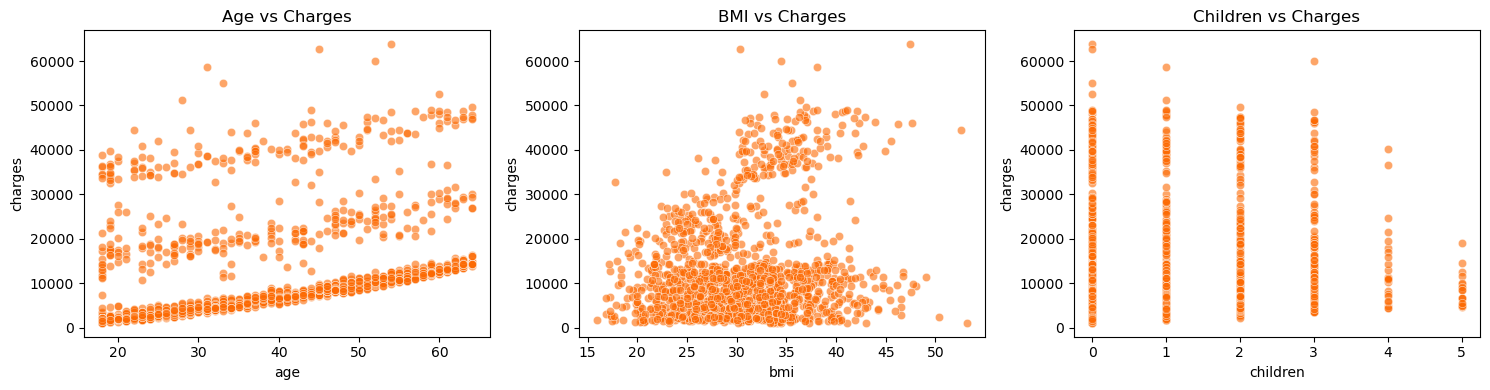

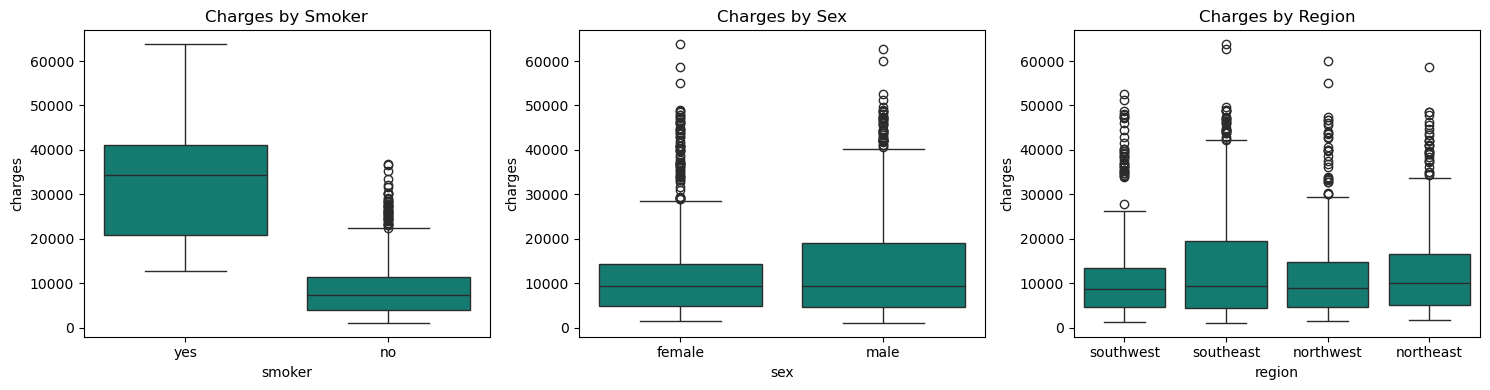

In [34]:
# Scatter plots of numeric variables vs charges
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age vs charges
sns.scatterplot(
    data=df, x="age", y="charges",
    alpha=0.6, color="#FC6A03", ax=axes[0]
)
axes[0].set_title("Age vs Charges")

# BMI vs charges
sns.scatterplot(
    data=df, x="bmi", y="charges",
    alpha=0.6, color="#FC6A03", ax=axes[1]
)
axes[1].set_title("BMI vs Charges")

# Children vs charges
sns.scatterplot(
    data=df, x="children", y="charges",
    alpha=0.6, color="#FC6A03", ax=axes[2]
)
axes[2].set_title("Children vs Charges")

plt.tight_layout()
plt.show()


# Box plots of categorical variables vs charges
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Smoker
sns.boxplot(
    data=df, x="smoker", y="charges",
    color="#048C7F", ax=axes[0]
)
axes[0].set_title("Charges by Smoker")

# Sex
sns.boxplot(
    data=df, x="sex", y="charges",
    color="#048C7F", ax=axes[1]
)
axes[1].set_title("Charges by Sex")

# Region
sns.boxplot(
    data=df, x="region", y="charges",
    color="#048C7F", ax=axes[2]
)
axes[2].set_title("Charges by Region")

plt.tight_layout()
plt.show()

I referenced Problem Set 7: Regression to help me with the visuals so that it can be lined it side by side to help with visually compare it easier.

Looking at these visuals side by side makes the patterns really clear. The numeric scatterplots show that age and BMI both trend upward with higher medical charges, even with a lot of noise. The children plot doesn’t show much structure, which suggests that the number of dependents alone isn’t driving costs in a strong way. The categorical boxplots highlight the biggest separation in the whole dataset because smokers consistently have much higher charges than non-smokers. Sex and region, on the other hand, show overlapping distributions with only small differences. Laying everything out in rows like this helps me quickly see which variables actually matter at a bivariate level before moving into modeling.

(b) Fit a multiple linear regression model. How much variance in the medical costs(charges) does this variable- bmi explain?

In [38]:
# Full multiple regression (with BMI)
full_model = smf.ols(
    "charges ~ age + bmi + children + sex + smoker + region",
    data=df
).fit()

# Reduced model (everything except BMI)
reduced_model = smf.ols(
    "charges ~ age + children + sex + smoker + region",
    data=df
).fit()

# R-squared values
r2_full = full_model.rsquared
r2_reduced = reduced_model.rsquared

print("R-squared (full model):   ", r2_full)
print("R-squared (no bmi model): ", r2_reduced)

# Partial R-squared for BMI (variance explained uniquely by BMI)
partial_r2_bmi = (r2_full - r2_reduced) / (1 - r2_reduced)
print("Partial R-squared for bmi:", partial_r2_bmi)

R-squared (full model):    0.7509130345985205
R-squared (no bmi model):  0.7245494196468011
Partial R-squared for bmi: 0.09571087095882856


To figure out how much variance BMI explains in medical charges, I fit two regression models, one that includes BMI and one that doesn’t. The idea is that if removing BMI causes the R^2 to drop, that drop reflects how much unique variance BMI was contributing to the full model. Using the OLS formula syntax keeps the code simple and readable, and comparing the two R^2 values lets me calculate BMI’s partial R^2. This gives a cleaner understanding of BMI’s impact after controlling for the other predictors in the model.

The results show that the full model (with BMI included) explains about 75.1% of the variance in medical charges. When I remove BMI from the model, the R^2 drops to about 72.5%. That difference may seem minimal, but once I calculate the partial R^2, BMI ends up accounting for roughly 9.6% of the variance in charges on its own, after controlling for all the other predictors.

This tells me that BMI does have a meaningful impact on medical costs, but it’s not the dominant driver, especially compared to something like smoking, which creates much larger separation in the earlier plots. BMI contributes its own unique piece of information to the model, but it’s one part of a broader set of factors influencing overall healthcare spending.

(c) Evaluate the statistical assumptions in your regression analysis from part (b) by performing a basic analysis of model residuals and any unusual observations. Discuss any concerns you have about your model.

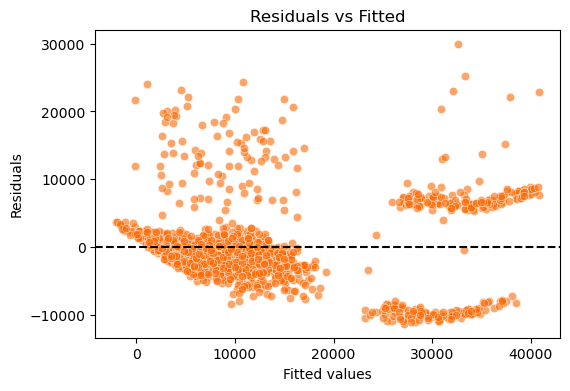

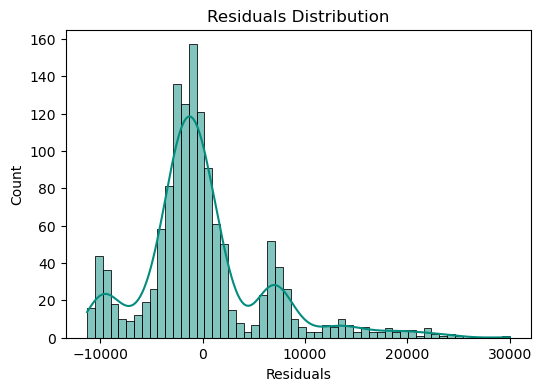

In [40]:
# Get residuals and fitted values
residuals = full_model.resid
fitted = full_model.fittedvalues

# Residuals vs Fitted
plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=residuals, alpha=0.6, color="#FC6A03")
plt.axhline(0, color="black", linestyle="--")
plt.title("Residuals vs Fitted")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

# Histogram of residuals
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True, color="#048C7F")
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.show()

Looking at the residual plots, the patterns aren’t as random as I’d hope for in a linear model. The spread of the residuals gets much wider as the fitted values increase, which tells me the model struggles more with high-cost individuals. The histogram also shows a clear right-skew, which makes sense given how extreme some medical charges can be. Altogether, this suggests the model isn’t meeting the constant-variance assumption and is being pulled by several very large observations. The linear model is still useful for a basic analysis, but I’d keep these limitations in mind because the residuals show that the data don’t fit the assumptions perfectly.

(d) Use a stepwise model selection procedure of your choice to obtain a "best" fit model. Is the model different from the full model you fit in part (b)? If yes, how so?

In [42]:
import itertools

# Candidate predictors
predictors = ["age", "bmi", "children", "sex", "smoker", "region"]

# Start with an empty model
best_aic = float("inf")
best_model = None
best_formula = None

# Try adding predictors one by one
for k in range(1, len(predictors) + 1):
    for combo in itertools.combinations(predictors, k):
        
        formula = "charges ~ " + " + ".join(combo)
        model = smf.ols(formula, data=df).fit()
        
        if model.aic < best_aic:
            best_aic = model.aic
            best_model = model
            best_formula = formula

best_formula, best_aic

('charges ~ age + bmi + children + smoker + region', 27111.66243447257)

I chose to use AIC for the stepwise selection because it gives me a simple way to balance model fit with model complexity. Instead of only focusing on how well the model explains variance, AIC also penalizes adding unnecessary predictors. That makes it a good tool when I want to avoid overfitting but still keep variables that genuinely improve the model. For this, it felt like the right choice because it let me compare a lot of different predictor combinations without getting too deep into more complicated selection methods. AIC gives a clear “lower is better” metric, so it was an easy and transparent way to decide which version of the model made the most sense to keep.

The results landed on the exact same set of predictors as the full model I fit earlier. This tells me that each variable contributed enough information to lower the AIC, so nothing was dropped. In other words, the full model was already the best-fitting one under this criterion. So in this case, stepwise didn’t simplify anything, it confirmed the structure I already had.

EXTRA CREDIT (Max point: 2) : Fit a regression tree using the same covariates in your "best" fit model from part (d). Use cross validation to select the "best" tree. Compare the models from part (d) and (f) based on their performance. Which do you prefer? Be sure to justify your preference.

### Problem 4

Points: 20

The Wisconsin Breast Cancer dataset is available on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original). Our goal in this problem will be to predict whether observations (i.e. tumors) are malignant or benign. We will use the original dataset in this problem. 

(a) Obtain the data and load it into your programming environment by pulling it directly from the web (links provided below). (Do **not** download it and import it from a CSV file.) Give a brief description of the data. 

In [44]:
# Web location of data file
location = "http://archive.ics.uci.edu/ml/machine-learning-databases/"
dataframe = "breast-cancer-wisconsin/breast-cancer-wisconsin.data"

# Column names from dataset documentation
col_names = [
    "id",
    "clump_thickness",
    "uniformity_cell_size",
    "uniformity_cell_shape",
    "marginal_adhesion",
    "single_epithelial_cell_size",
    "bare_nuclei",
    "bland_chromatin",
    "normal_nucleoli",
    "mitosis",
    "class"
]

# Load dataset
df = pd.read_csv(location + dataframe, header=None, names=col_names)
df.head()

,id,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitosis,class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


The Wisconsin Breast Cancer dataset contains clinical measurements taken from fine-needle aspirates of breast tumors. Each row represents a single tumor sample, and the dataset includes 699 observations. There are 10 predictor variables, each rated on a 1–10 scale to describe different cell characteristics such as clump thickness, uniformity of cell size and shape, bare nuclei, and mitosis. The last column is the class label, indicating whether the tumor is benign (2) or malignant (4).

(b) Investigate the data, ensuring that each variable is properly named and cast as the correct data type. Discuss any missing data.

In [46]:
# Check the structure of the dataset
df.info()

# There are missing values in bare_nuclei, so replace it with NaN
df["bare_nuclei"] = df["bare_nuclei"].replace("?", pd.NA)

# Cast bare_nuclei to numeric
df["bare_nuclei"] = pd.to_numeric(df["bare_nuclei"])

# Double-check data types
df.dtypes

# Look at missing values
df.isna().sum()

# Drop missing rows
df_clean = df.dropna().copy()
df_clean.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   id                           699 non-null    int64 
 1   clump_thickness              699 non-null    int64 
 2   uniformity_cell_size         699 non-null    int64 
 3   uniformity_cell_shape        699 non-null    int64 
 4   marginal_adhesion            699 non-null    int64 
 5   single_epithelial_cell_size  699 non-null    int64 
 6   bare_nuclei                  699 non-null    object
 7   bland_chromatin              699 non-null    int64 
 8   normal_nucleoli              699 non-null    int64 
 9   mitosis                      699 non-null    int64 
 10  class                        699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB


(683, 11)

After checking the structure of the dataset, all 11 variables loaded with the correct column names. Most of the predictors came in as integers, which matches what we expect since all diagnostic features are scored on a 1–10 scale.

The one issue that showed up is with bare_nuclei. Because the original dataset uses "?" to mark missing values, pandas treated that entire column as an object instead of a numeric type. After replacing "?" with NaN and converting the column to numeric, everything lines up correctly.

When I inspected missing values, bare_nuclei is the only variable with missing data, 16 rows total. All other columns are complete. Since 16 missing rows out of 699 is a small proportion, dropping those observations is a reasonable option. After removing them, the cleaned dataset has 683 rows.

(c) Split the data into a training and test set such that a random 70\% of the observations are in the training set.

In [47]:
from sklearn.model_selection import train_test_split

# Separate predictors and outcome
X = df_clean.drop("class", axis=1)
y = df_clean["class"]

# 70/30 train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

X_train.shape, X_test.shape

((478, 10), (205, 10))

Since 70% of the observations are in the training set, it made sense to make 30% as testing. This gives the model enough data to learn meaningful patterns while still reserving a solid chunk to test performance. I also set random_state=42 just to make the split reproducible, so every time I run this code, I get the exact same partition. I separated the predictors (X) from the outcome (y) and then applied train_test_split() using the cleaned dataset.

After splitting the cleaned dataset, I ended up with 478 observations in the training set and 205 in the test set, which aligns with the 70/30 ratio I specified. Each set contains all 10 predictor variables, and setting a random seed ensures the split is consistent every time I run the code.

(d) Fit a ML model to predict whether tissue samples are malignant or benign. Then use your model to classify cases in your test set, which is the remaining 30% of the all the observations. Compute and discuss the resulting confusion matrix. Be sure to address which of the errors that are identified you consider most problematic in this context.

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# Fit a logistic regression model on the training data
log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train, y_train)

# Use the model to predict class labels for the test set
y_pred = log_reg.predict(X_test)

# Confusion matrix with explicit label order: 2 = benign, 4 = malignant
labels = [2, 4]
cm = confusion_matrix(y_test, y_pred, labels=labels)

cm_df = pd.DataFrame(
    cm,
    index=["Benign (true)", "Malignant (true)"],
    columns=["Benign (pred)", "Malignant (pred)"]
)

cm_df

,Benign (pred),Malignant (pred)
Benign (true),125,2
Malignant (true),7,71


I trained the model using the 70% training set and increased max_iter to ensure the optimization process converged. Once the model was fitted, I used it to predict the class labels for the 30% test set, these are cases the model hasn’t seen before, so they give an honest evaluation of performance. To understand how well the model performed, I computed the confusion matrix using the known true labels and the model’s predicted labels. I also ordered the labels so that benign (2) and malignant (4) appear in a consistent and readable structure. Converting the matrix into a small DataFrame made it easier to interpret the results.

The confusion matrix shows that the logistic regression model performed very well on the test set. The model correctly identified 125 benign tumors and 71 malignant tumors. There were 2 false positives, where benign cases were incorrectly labeled as malignant, and 7 false negatives, where malignant tumors were predicted as benign. In a medical context, the false negatives are the most concerning errors because they represent missed malignant tumors, which could delay diagnosis and treatment. False positives may lead to unnecessary follow-up tests and anxiety, but they are far less serious than failing to detect an actual cancer. Overall, the model suggests strong predictive performance, with relatively low misclassification rates and high accuracy across both classes.

### Problem 5

Points: 10

Please answer the questions below by writing a short response. 

(a) Describe three real-life applications in which **classification** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

In Formula 1, classification can be used to predict whether a driver will finish in the points. The response would be a simple yes/no outcome, and the predictors might include qualifying position, tire compound choices, pit strategy, track temperature, and overall team performance metrics. The goal here is really prediction, since the main interest is forecasting race outcomes in real time rather than explaining the underlying mechanics.

In football or baseball, a classification model could help identify whether a player is at high or low risk of injury before an upcoming game. The response would be injury-risk level, and the predictors could include recent workload, playing time, past injuries, position-specific demands, and biomechanical data. The goal is clearly prediction, because coaches and analysts want to prevent injuries by anticipating them ahead of time.

In my work at UPrep, I could use classification to predict whether a donor is likely to give again this year. The response would be a yes/no indicator of future giving, with predictors such as past donation history, event attendance, email engagement, pledge patterns, and even alum class year. In this case, the goal is a mix of inference and prediction so I’d want to understand what drives donor behavior, but also use those insights to forecast giving patterns for planning and stewardship.

b) Describe three real-life applications in which **regression** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

In Formula 1, regression could be used to predict a driver’s lap time. The response would be the actual lap time in seconds, and the predictors might include tire age, fuel load, track temperature, sector speeds, and downforce setup. The goal here is prediction, since teams want accurate forecasts to plan pit strategy and race pace.

In baseball, regression is useful for estimating a player’s expected batting average or slugging percentage. The response could be the player’s season-long batting average, and predictors might include exit velocity, launch angle, plate discipline stats, and past performance. This leans toward inference and prediction because teams want to understand why certain skills drive performance, but they also want a model that predicts future production.

In my work at UPrep, a regression model could help forecast total fundraising dollars for the year. The response would be annual giving amount, and predictors could include donor count, historical trends, pledge fulfillment rates, event attendance, and email engagement metrics. This is mostly prediction, because the goal is to estimate year-end revenue so we can plan budgets and stewardship, though understanding which variables matter is still helpful.

(c) What are the advantages and disadvantages of a very flexible (versus a less flexible) approach for regression or classification? Under what circumstances might a more flexible approach be preferred to a less flexible approach? When might a less flexible approach be preferred?

A more flexible approach such as random forests, boosted trees, or highly tuned neural nets can capture complex, nonlinear patterns that simpler models would miss. This usually means better predictive performance, especially when the data has a lot of structure. The downside is that flexible models are harder to interpret, more prone to overfitting, and often require more data and tuning. You get power, but you lose transparency.

A less flexible approach such as linear regression or logistic regression is easier to interpret and much more stable. These models help you understand the relationships between variables, and they’re less likely to overfit, especially with smaller datasets. The trade-off is that they may miss important nonlinear patterns, which can limit predictive accuracy.

A more flexible approach is preferred when your main goal is prediction and you have plenty of data. For example, forecasting lap times in Formula 1 or predicting injury risk with large amounts of player tracking data. A less flexible approach is better when you care about interpretability or when the dataset is smaller or cleaner like understanding which fundraising metrics drive donor behavior or explaining performance patterns to stakeholders who need simple, defensible results.

### Problem 6

Points: 10

Suppose we have a dataset with five predictors, $X_1 =$ GPA, $X_2 =$ IQ, $X_3 =$ Gender (1 for Female, and 0 for Male), $X_4 =$ Interaction between GPA and IQ, and $X_5 =$ Interaction between GPA and Gender. Note: the data here is limited as gender was collected as a binary variable.

The response is starting salary after graduation (in thousands of dollars). Suppose we use least squares to fit the model and get $\hat{\beta}_0=50, \hat{\beta}_1=20, \hat{\beta}_2=0.07, \hat{\beta}_3=35, \hat{\beta}_4=0.01$, and $\hat{\beta}_5=-10$. 

(a) Which answer is correct and why? <font color = red>[single choice question]

i. For a fixed value of IQ and GPA, males earn more on average than females.

ii. For a fixed value of IQ and GPA, females earn more on average than males.

iii. For a fixed value of IQ and GPA, males earn more on average than females provided that the GPA is high enough.

iv. For a fixed value of IQ and GPA, females earn more on average than males provided that the GPA is high enough.

The answer would be iii. For a fixed value of IQ and GPA, males earn more on average than females provided that the GPA is high enough.

To figure out whether males or females earn more (holding GPA and IQ fixed), I started by writing out the regression equation for each group. Since gender is coded as 1 for females and 0 for males, I can plug those values in and compare the predictions directly.

The original model is: Y^ = 50+20GPA+0.07IQ+35Gender+0.01(GPAxIQ)−10(GPAxGender)

When Gender = 0, all Gender terms drop out: Y^M = 50+20GPA+0.07IQ+0.01(GPAxIQ)

When Gender = 1, the model becomes: Y^F = 50+20GPA+0.07IQ+35+0.01(GPAxIQ)−10GPA

Difference (Female − Male)

To compare salaries directly, I subtract the male equation from the female equation: Y^F−Y^M = 35−10GPA

This simplifies the problem to a single expression that depends only on GPA:

If GPA is low, then 35−10GPA > 0, meaning females earn more.

If GPA is high, then 35−10GPA < 0, meaning males earn more.

When GPA = 3.5, the difference is exactly zero.

(b) Wite down the least square function and then predict the salary of a female with IQ of 110 and a GPA of 4.0.

In [50]:
# Least squares regression function (based on the fitted model)
def predict_salary(gpa, iq, gender):
    return (
        50
        + 20 * gpa
        + 0.07 * iq
        + 35 * gender
        + 0.01 * (gpa * iq)
        - 10 * (gpa * gender)
    )

# Predict salary for a female with IQ = 110 and GPA = 4.0
gpa = 4.0
iq = 110
gender = 1   # female

salary_pred = predict_salary(gpa, iq, gender)
salary_pred

137.1

(c) True or false: Since the coefficient for the GPA/IQ interaction term is very small, there is little evidence of an interaction effect. Justify your answer.

False.

The coefficient looks small (0.01), but interaction terms are multiplied by the product of the predictors. For example (GPA x IQ), a student with GPA=4 and IQ =110 > 0.01×(4×110)= 0.01×440=4, which is a $4,000 change in predicted salary (since the units are thousands). That’s not tiny. Also, “evidence of interaction” isn’t about the raw size of the coefficient by itself, it depends on its standard error and p-value (i.e., whether the term is statistically significant). So we can’t say there is “little evidence” of an interaction just because the number 0.01 looks small.

### Problem 7 - Extra Credit

Points: Max. 4

Suppose that $X_1, \ldots X_n$ form a random sample from a Poisson distribution for which the mean $\theta$ is unknown, $(\theta>0)$.

(a) Determine the MLE of $\theta$, assuming that at least one of the observed values is different from 0. Show your work.

In [51]:
# sample data (replace with your actual Xi's)
x = np.array([2, 0, 3, 1, 4])

# MLE for theta is just the sample mean
theta_hat = x.mean()

theta_hat

2.0

Reference: Cetinkaya-Rundel, M., Diez, D., & Barr, C. (2019). OpenIntro Statistics. (Fourth Edition ed.) OpenIntro, Inc.

I referenced pages 163-165 to help me answer the above. It took me a bit to figure out the LaTeX writing to show the formulas correctly in a Markdown cell. I had to look back at past problem sets and labs to figure out the right coding.

For a Poisson random variable with mean $( \theta )$, the pmf is

$
P(X_i = x_i \mid \theta) = \frac{e^{-\theta}\,\theta^{x_i}}{x_i!}.
$

For a random sample $( X_1, \ldots, X_n )$, the likelihood is

$
L(\theta) = \prod_{i=1}^n \frac{e^{-\theta}\,\theta^{x_i}}{x_i!}
          = e^{-n\theta}\,\theta^{\sum_{i=1}^n x_i}\,\prod_{i=1}^n \frac{1}{x_i!}.
$

Taking the natural log of the likelihood:

$
\ell(\theta) = -n\theta + \left( \sum_{i=1}^n x_i \right)\log(\theta) + \text{constant}.
$

Differentiate with respect to $( \theta )$:

$
\frac{d\ell}{d\theta} = -n + \frac{\sum_{i=1}^n x_i}{\theta}.
$

Set the derivative equal to zero and solve:

$
-n + \frac{\sum_{i=1}^n x_i}{\theta} = 0
\quad\Rightarrow\quad
\theta = \frac{1}{n} \sum_{i=1}^n x_i.
$

MLE Result

$
\hat{\theta}_{\text{MLE}} = \bar{X}.
$

Having at least one nonzero observation ensures the estimate is positive and avoids the boundary case $( \theta = 0 )$.

(b) Show that the MLE of $\theta$ does not exists if every observed value is 0.

MLE when all observed values are 0

Suppose $(X_1, \ldots, X_n)$ are i.i.d. $(\text{Poisson}(\theta))$, and every single observation is 0, i.e. $(x_i = 0)$ for all $(i)$.

For one observation,
$
P(X_i = 0 \mid \theta) = \frac{e^{-\theta}\theta^0}{0!} = e^{-\theta}.
$

This means the likelihood for the entire sample becomes
$
L(\theta) = \prod_{i=1}^n e^{-\theta} = e^{-n\theta}.
$

Taking logs gives us
$
\ell(\theta) = \log L(\theta) = -n\theta.
$

For $(\theta > 0)$, the log-likelihood is a straight line that keeps going down as $(\theta$) increases. So the only way to make the likelihood as large as possible is to push $(\theta)$ closer and closer to 0. So this means that the "best" value is right at the edge of the parameter space.

However, if the parameter space is $((0, \infty))$, then $(\theta = 0)$ is not allowed, so the maximum is never actually attained. Therefore, the MLE does not exist in $((0, \infty))$ when all observations are 0.

If we instead allowed $(\theta \ge 0)$, then the MLE would be $(\hat{\theta} = 0).$

### Problem 8 - Extra Credit

Points: Max. 4

In this extra credit problem, you'll build a simple web scraper to collect and process text data. You'll write the code necessary to scrape lyrics for a desired artist. Your code should be structured such that one can easily execute your scraping functions for a given artist. There are three deliverables for this assignment:

1. A set of functions necessary for scraping the lyrics of a specific artist.
2. An example implementation of using your functions.
3. A file of example output from your notebook implementation.

The specific approach that you take to structuring your code is up to you, but the final output .csv data should have the following columns (each row is a song from an artist that you choose):

- Column 1: artist
- Column 2: album
- Column 3: song title
- Column 4: URL of song lyrics
- Column 5: song lyrics (all of the lyrics in one column)
- Column 6: number of words in the song

**Data Scraping:** The actual scraping of data should be supported by separate functions that accomplish these tasks:

1. Given an artist, identify all of their albums, songs, and links to songs.
2. Given a set of song links (from step 1), collect the lyrics to each song and store them in a data frame.

In order to do this, you'll need to understand the structure of your lyrics site. The site you use is up to you, but all of this information should be available on lyrics.com.

**Data Processing:**

Once you've scraped the data, you'll need to do some simple text analysis to generate your columns of interest (feel free to do this as part of step 2 above, the collection of lyrics for each song or as a separate step entirely). Recall you are aiming to count the number of words in each song.

**Example Implementation:**

You should demonstrate the implementation of your data scraping functions with a particular artist. To do this you can simply set an artist, and run your scraping functions. The way in which you choose to structure your functions is up to you, as long as the implementation and documentation is clear. One way in which we'll test this is changing the artist to confirm the flexibility of your implementation. 

It may look something like this:

In [ ]:
# NOTE THIS CODE WILL NOT RUN 
# UNTIL YOU WRITE YOUR WEB SCRAPING FUNCTIONS

# Get songs
artist = 'Adele'
all_songs = get_songs(artist) 

# Get lyrics -- internally, you may want to another function in your library, such as get_lyrics()
lyrics = get_all_lyrics(songs)

# Save data -- this function should identify the name of the artist and use it in the .csv file it saves
save_lyrics(lyrics)

(a) Write a function to get all the songs of a particular artist. 

(b) Write a function to get all the lyrics for a particular song. You may also want to write a function to get all the lyrics for a list of songs.  

(c) Choose a particular artist. Get all their songs. Get all the lyrics for their songs. Process the data so that you end up with a nice, tidy data structure as described in the instructions (i.e. the six columns listed above). Write out the data to a CSV file.  

(d) Produce one visualization of the data to aids in understanding the distribution of words in songs for a particular artist. Comment on what you find.  